<a href="https://colab.research.google.com/github/Ashish280411/ML-Projects./blob/main/Smart_Electricity_Theft_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
print("Smart Electricity Theft Detection")

Smart Electricity Theft Detection


In [18]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully")

All libraries imported successfully


In [20]:
df = pd.read_csv(
    "smart_meter_data.csv",
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [21]:
df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [22]:
df.shape


(5000, 7)

In [23]:
df.columns

Index(['Timestamp', 'Electricity_Consumed', 'Temperature', 'Humidity',
       'Wind_Speed', 'Avg_Past_Consumption', 'Anomaly_Label'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB


In [25]:
df.isnull().sum()

,0
Timestamp,0
Electricity_Consumed,0
Temperature,0
Humidity,0
Wind_Speed,0
Avg_Past_Consumption,0
Anomaly_Label,0


In [26]:
df["Anomaly_Label"].value_counts()

,count
Anomaly_Label,
Normal,4750
Abnormal,250


In [27]:
# Duplicate rows check
print("Duplicate rows:", df.duplicated().sum())

# Missing values check
print("\nMissing values:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values:
Timestamp               0
Electricity_Consumed    0
Temperature             0
Humidity                0
Wind_Speed              0
Avg_Past_Consumption    0
Anomaly_Label           0
dtype: int64


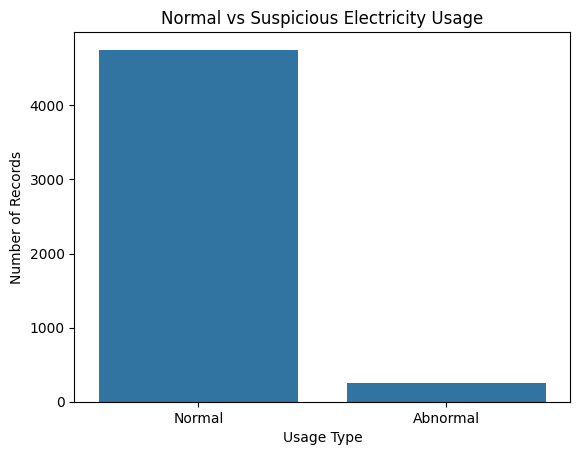

In [28]:
sns.countplot(data=df, x="Anomaly_Label")

plt.title("Normal vs Suspicious Electricity Usage")
plt.xlabel("Usage Type")
plt.ylabel("Number of Records")

plt.show()

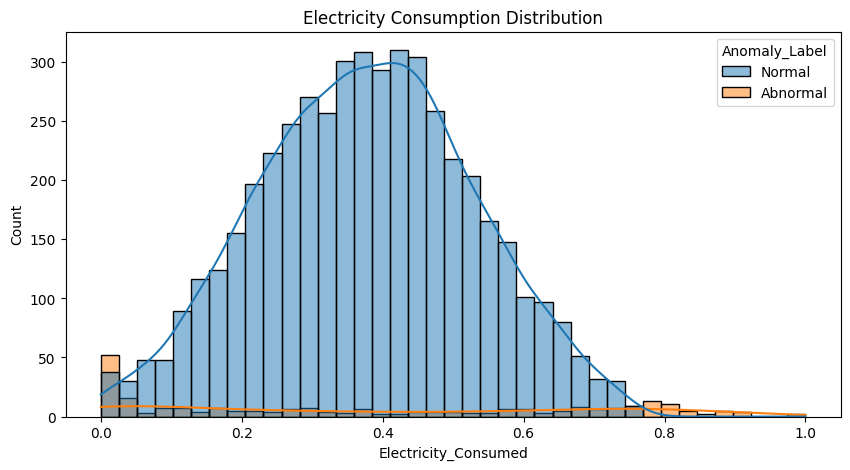

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Electricity_Consumed",
    hue="Anomaly_Label",
    kde=True
)

plt.title("Electricity Consumption Distribution")
plt.show()

In [30]:
print(df["Anomaly_Label"].unique())

['Normal' 'Abnormal']


In [54]:
import pandas as pd

df = pd.read_csv("/content/smart_meter_data.csv")

df["Anomaly_Label"] = df["Anomaly_Label"].str.strip().map({
    "Normal": 0,
    "Abnormal": 1
})

In [32]:
df["Anomaly_Label"].value_counts()

,count
Anomaly_Label,
0,4750
1,250


In [33]:
X = df.drop(
    ["Anomaly_Label", "Timestamp"],
    axis=1
)

y = df["Anomaly_Label"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 5)
Testing data: (1000, 5)


In [35]:
print(df["Anomaly_Label"].unique())

[0 1]


In [36]:

df["Anomaly_Label"] = df["Anomaly_Label"].astype(int)

print(df["Anomaly_Label"].value_counts())

Anomaly_Label
0    4750
1     250
Name: count, dtype: int64


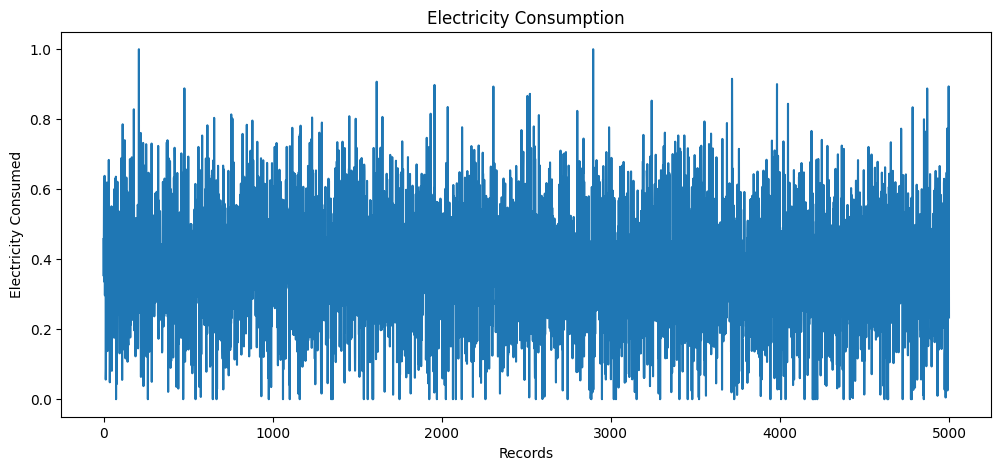

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["Electricity_Consumed"])
plt.title("Electricity Consumption")
plt.xlabel("Records")
plt.ylabel("Electricity Consumed")
plt.show()

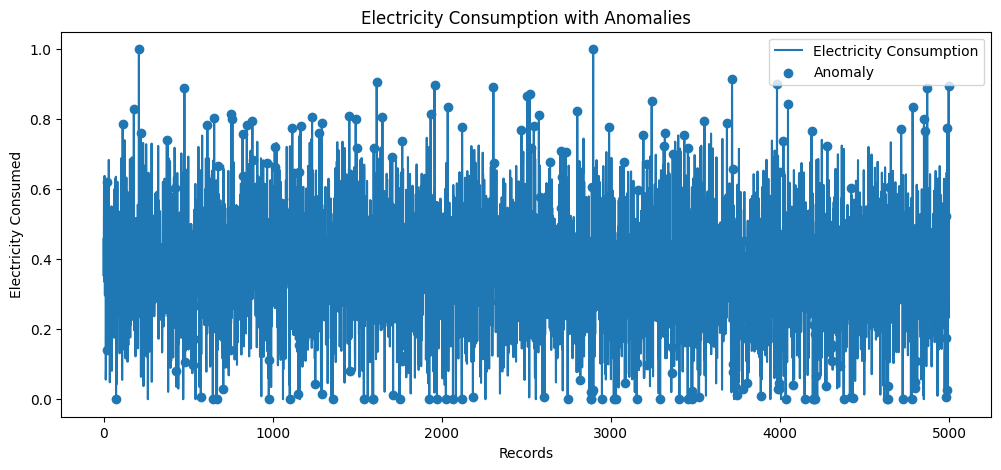

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(df["Electricity_Consumed"], label="Electricity Consumption")

anomaly_data = df[df["Anomaly_Label"] == 1]

plt.scatter(
    anomaly_data.index,
    anomaly_data["Electricity_Consumed"],
    label="Anomaly"
)

plt.title("Electricity Consumption with Anomalies")
plt.xlabel("Records")
plt.ylabel("Electricity Consumed")
plt.legend()
plt.show()

In [39]:
print(df.isnull().sum())

Timestamp               0
Electricity_Consumed    0
Temperature             0
Humidity                0
Wind_Speed              0
Avg_Past_Consumption    0
Anomaly_Label           0
dtype: int64


In [40]:
df = df.dropna()
print(df.shape)

(5000, 7)


In [41]:
X = df.drop(columns=["Timestamp", "Anomaly_Label"])
y = df["Anomaly_Label"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 5)
(1000, 5)


In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.986
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       950
           1       0.91      0.80      0.85        50

    accuracy                           0.99      1000
   macro avg       0.95      0.90      0.92      1000
weighted avg       0.99      0.99      0.99      1000



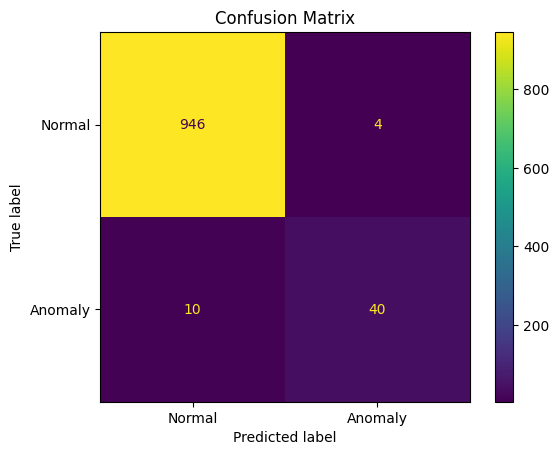

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display_cm.plot()
plt.title("Confusion Matrix")
plt.show()

In [46]:
importance = model.feature_importances_

for feature, value in zip(X.columns, importance):
    print(feature, ":", value)

Electricity_Consumed : 0.4111846784724143
Temperature : 0.050372835108479765
Humidity : 0.038602249452099016
Wind_Speed : 0.045263109510365857
Avg_Past_Consumption : 0.4545771274566411


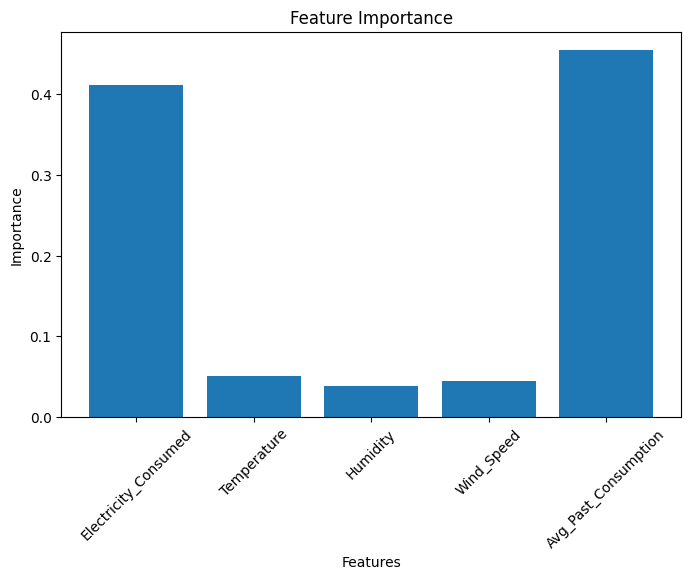

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(X.columns, model.feature_importances_)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [48]:
new_data = [[
    5.2,    # Electricity_Consumed
    30,     # Temperature
    60,     # Humidity
    10,     # Wind_Speed
    4.8     # Avg_Past_Consumption
]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Anomaly Detected")
else:
    print("Normal Consumption")

Anomaly Detected


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [49]:
probability = model.predict_proba(new_data)

print("Normal Probability:", probability[0][0])
print("Anomaly Probability:", probability[0][1])

Normal Probability: 0.15
Anomaly Probability: 0.85


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [50]:
import joblib

joblib.dump(model, "smart_meter_anomaly_model.pkl")

['smart_meter_anomaly_model.pkl']

In [51]:
from google.colab import files

files.download("smart_meter_anomaly_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>